In [41]:
import pandas as pd

athletes = pd.read_csv(r'C:\Users\jazmi\2016_olimpics\data\raw\athletes.csv', encoding='latin-1')
countries = pd.read_csv(r'C:\Users\jazmi\2016_olimpics\data\raw\countries.csv', encoding='latin-1')
events = pd.read_csv(r'C:\Users\jazmi\2016_olimpics\data\raw\events.csv', encoding='latin-1')

print("ATHLETES:", athletes.columns.tolist())
print("COUNTRIES:", countries.columns.tolist())
print("EVENTS:", events.columns.tolist())

print("\nATHLETES shape:", athletes.shape)
print("COUNTRIES shape:", countries.shape)
print("EVENTS shape:", events.shape)

ATHLETES: ['id', 'name', 'nationality', 'sex', 'dob', 'height', 'weight', 'sport', 'gold', 'silver', 'bronze']
COUNTRIES: ['country', 'code', 'population', 'gdp_per_capita']
EVENTS: ['id', 'sport', 'discipline', 'name', 'sex', 'venues']

ATHLETES shape: (11538, 11)
COUNTRIES shape: (201, 4)
EVENTS shape: (306, 6)


In [42]:
#Nulos
print("\nATHLETES:\n", athletes.isnull().sum())
print("\nCOUNTRIES:\n", countries.isnull().sum())
print("\nEVENTS:\n", events.isnull().sum())


ATHLETES:
 id               0
name             0
nationality      0
sex              0
dob              1
height         330
weight         659
sport            0
gold             0
silver           0
bronze           0
dtype: int64

COUNTRIES:
 country            0
code               0
population         5
gdp_per_capita    25
dtype: int64

EVENTS:
 id            0
sport         0
discipline    0
name          0
sex           0
venues        0
dtype: int64


In [43]:
#Merge

#Athletes+ Countries (nacionalidad)
df = athletes.merge(
    countries,
    left_on='nationality',
    right_on='code',
    how='left'
)

#+ Events (sport y sex)
df = df.merge(
    events,
    on=['sport', 'sex'],
    how='left'
)

In [44]:
#Limpieza

#Eliminar columna duplicada 
df.drop(columns=['code'], inplace=True)

#Renombrar columnas 
df.rename(columns={
    'id_x': 'athlete_id',
    'id_y': 'event_id',
    'name_x': 'athlete_name',
    'name_y': 'event_name'
}, inplace=True)

#Convertir tipo de datos
df['dob'] = pd.to_datetime(df['dob'], format='%m/%d/%y', errors='coerce')
df['dob'] = df['dob'].apply(lambda x: x.replace(year=x.year - 100) if pd.notnull(x) and x.year > 2016 else x)

#Calcular edad
olympics_date = pd.Timestamp('2016-08-05')
df['age'] = ((olympics_date - df['dob']).dt.days / 365.25).apply(np.floor)

#Crear columna de edad al momento de los juegos (agosto 2016)
import numpy as np
olympics_date = pd.Timestamp('2016-08-05')
df['age'] = ((olympics_date - df['dob']).dt.days / 365.25).apply(np.floor)

In [45]:
print("Shape final:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nPrimeras filas:")
df.head()

Shape final: (125379, 19)

Columnas: ['athlete_id', 'athlete_name', 'nationality', 'sex', 'dob', 'height', 'weight', 'sport', 'gold', 'silver', 'bronze', 'country', 'population', 'gdp_per_capita', 'event_id', 'discipline', 'event_name', 'venues', 'age']

Primeras filas:


,athlete_id,athlete_name,nationality,sex,dob,height,weight,sport,gold,silver,bronze,country,population,gdp_per_capita,event_id,discipline,event_name,venues,age
0,736041664,A Jesus Garcia,ESP,male,1969-10-17,1.72,64.0,athletics,0,0,0,Spain,46418269.0,25831.582305,772822.0,combined,Men's Decathlon,Olympic Stadium,46.0
1,736041664,A Jesus Garcia,ESP,male,1969-10-17,1.72,64.0,athletics,0,0,0,Spain,46418269.0,25831.582305,236418.0,jumps,Men's High Jump,Olympic Stadium,46.0
2,736041664,A Jesus Garcia,ESP,male,1969-10-17,1.72,64.0,athletics,0,0,0,Spain,46418269.0,25831.582305,770978.0,jumps,Men's Long Jump,Olympic Stadium,46.0
3,736041664,A Jesus Garcia,ESP,male,1969-10-17,1.72,64.0,athletics,0,0,0,Spain,46418269.0,25831.582305,323149.0,jumps,Men's Pole Vault,Olympic Stadium,46.0
4,736041664,A Jesus Garcia,ESP,male,1969-10-17,1.72,64.0,athletics,0,0,0,Spain,46418269.0,25831.582305,606367.0,jumps,Men's Triple Jump,Olympic Stadium,46.0


In [46]:
#Exportar

#CSV expandido (atleta x evento)
df.to_csv(r'C:\Users\jazmi\2016_olimpics\data\processed\olympics_full.csv', index=False)

#CSV por atleta (sin duplicados de eventos)
df_athletes = df.drop_duplicates(subset='athlete_id').drop(columns=['event_id', 'discipline', 'event_name', 'venues'])
df_athletes.to_csv(r'C:\Users\jazmi\2016_olimpics\data\processed\olympics_athletes.csv', index=False)

print("olympics_full.csv:", df.shape)
print("olympics_athletes.csv:", df_athletes.shape)

olympics_full.csv: (125379, 19)
olympics_athletes.csv: (11538, 15)


In [47]:
#EDA

print("Estadísticas")
print(f"Total atletas: {df_athletes['athlete_id'].nunique()}")
print(f"Total países: {df_athletes['nationality'].nunique()}")
print(f"Total deportes: {df_athletes['sport'].nunique()}")
print(f"Atletas masculinos: {(df_athletes['sex']=='male').sum()}")
print(f"Atletas femeninos: {(df_athletes['sex']=='female').sum()}")
print(f"\nEdad promedio: {df_athletes['age'].mean():.1f} años")
print(f"Atleta más joven: {df_athletes['age'].min():.0f} años")
print(f"Atleta más grande: {df_athletes['age'].max():.0f} años")

Estadísticas
Total atletas: 11538
Total países: 207
Total deportes: 28
Atletas masculinos: 6333
Atletas femeninos: 5205

Edad promedio: 26.3 años
Atleta más joven: 13 años
Atleta más grande: 62 años


In [48]:
medals = df_athletes.groupby('country')[['gold','silver','bronze']].sum()
medals['total'] = medals['gold'] + medals['silver'] + medals['bronze']
medals = medals.sort_values('total', ascending=False).head(10)
print(medals)

                gold  silver  bronze  total
country                                    
United States    139      54      71    264
Germany           49      44      67    160
United Kingdom    64      55      26    145
Russia            52      29      34    115
China             46      30      37    113
France            20      54      21     95
Australia         23      34      25     82
Italy              8      40      24     72
Canada             4       4      61     69
Japan             17      13      35     65


In [49]:
top_sports = df_athletes['sport'].value_counts().head(10)
print(top_sports)

sport
athletics     2363
aquatics      1445
football       611
rowing         547
cycling        525
hockey         432
judo           392
shooting       390
volleyball     384
sailing        380
Name: count, dtype: int64


In [50]:
#Formato fechas
print(athletes['dob'].head(10))
print("\nTipo de dato:", athletes['dob'].dtype)

0    10/17/69
1     9/23/86
2     5/27/92
3      1/2/91
4    11/26/90
5     1/26/90
6      6/4/93
7     9/25/91
8    12/14/88
9     7/22/91
Name: dob, dtype: str

Tipo de dato: str


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

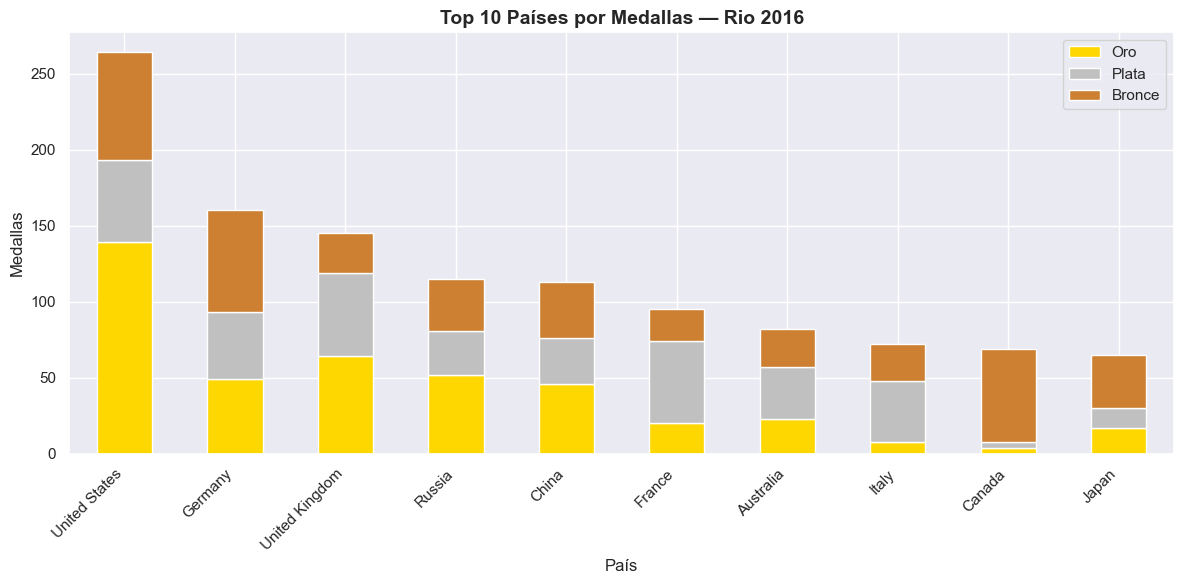

In [52]:
fig, ax = plt.subplots()
medals_plot = medals.drop(columns='total')
medals_plot.plot(kind='bar', stacked=True, ax=ax,
                 color=['#FFD700', '#C0C0C0', '#CD7F32'])
ax.set_title('Top 10 Países por Medallas — Rio 2016', fontsize=14, fontweight='bold')
ax.set_xlabel('País')
ax.set_ylabel('Medallas')
ax.legend(['Oro', 'Plata', 'Bronce'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r'C:\Users\jazmi\2016_olimpics\data\processed\top10_paises.png', dpi=150)
plt.show()

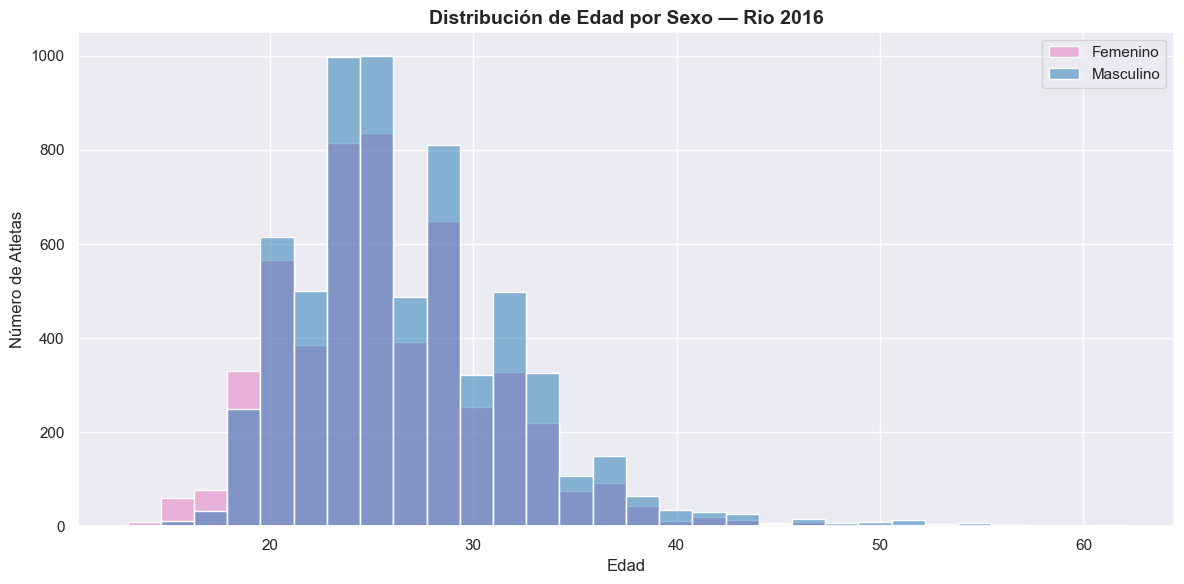

In [53]:
fig, ax = plt.subplots()
sns.histplot(data=df_athletes, x='age', hue='sex', bins=30, ax=ax,
             palette={'male': '#1f77b4', 'female': '#e377c2'})
ax.set_title('Distribución de Edad por Sexo — Rio 2016', fontsize=14, fontweight='bold')
ax.set_xlabel('Edad')
ax.set_ylabel('Número de Atletas')
ax.legend(['Femenino', 'Masculino'])
plt.tight_layout()
plt.savefig(r'C:\Users\jazmi\2016_olimpics\data\processed\edad_sexo.png', dpi=150)
plt.show()

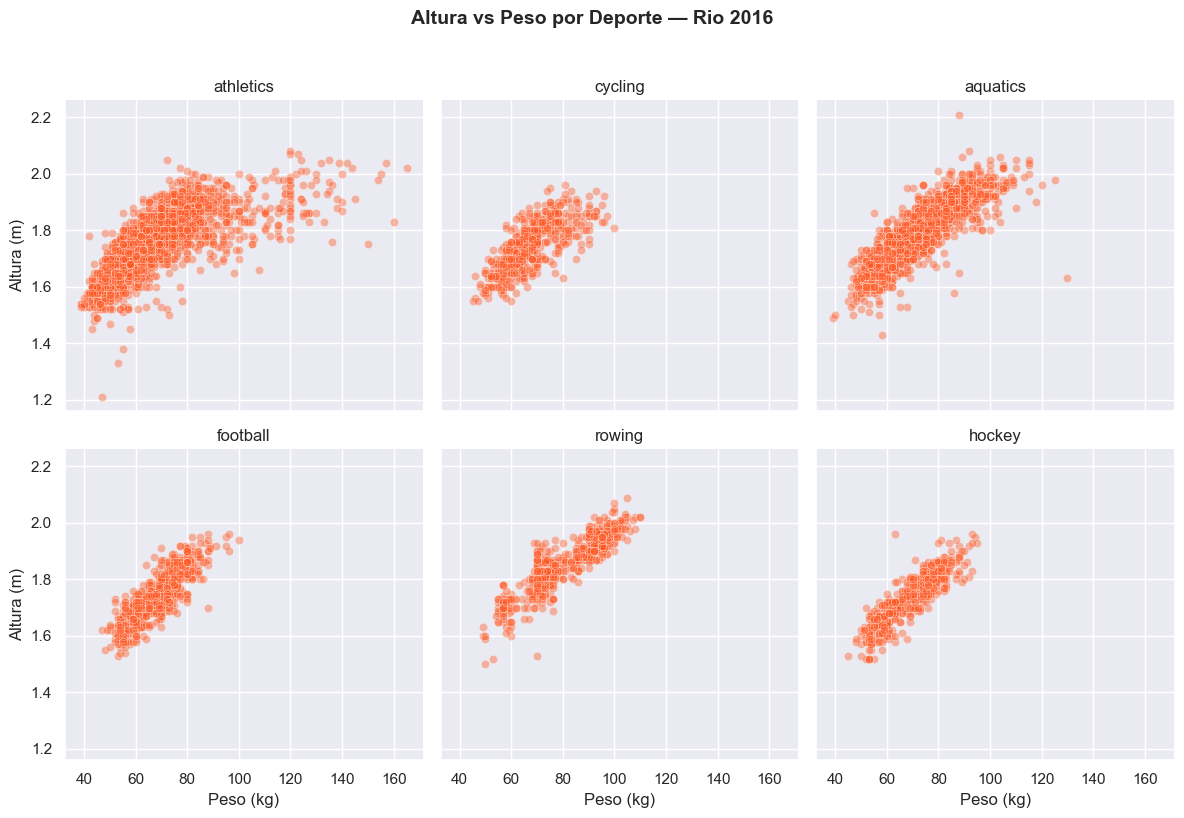

In [54]:
top6_sports = df_athletes['sport'].value_counts().head(6).index
df_top6 = df_athletes[df_athletes['sport'].isin(top6_sports)]

g = sns.FacetGrid(df_top6, col='sport', col_wrap=3, height=4)
g.map_dataframe(sns.scatterplot, x='weight', y='height', 
                alpha=0.4, color='#FF5722')
g.set_axis_labels('Peso (kg)', 'Altura (m)')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Altura vs Peso por Deporte — Rio 2016', 
                   fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\jazmi\2016_olimpics\data\processed\altura_peso.png', dpi=150)
plt.show()